<a href="https://colab.research.google.com/github/Jubayer934/Diabetes_ML_Project/blob/main/Diabetes_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1️⃣ Data Loading & Exploration

In [ ]:
import pandas as pd

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/ModelTrain/AI and ML Engineering /dataset/diabetes.csv")

In [ ]:
df.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [ ]:
df.shape

(768, 9)

In [ ]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
print("Number of zero values in each column:")
print(df.isin([0]).sum())

Number of zero values in each column:
Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64


In [ ]:
df['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


In [ ]:
total = df['Outcome'].sum()
total_diabetes = df['Outcome'].count()
print(f"Diabetes Patient rate : {(total/total_diabetes)*100:.2f}%")

Diabetes Patient rate : 34.90%


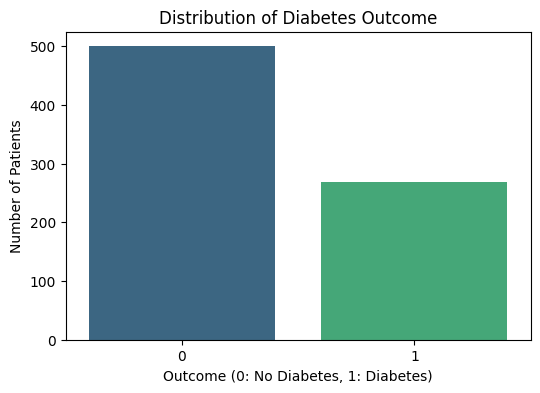

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.countplot(x='Outcome', data=df, palette='viridis', hue='Outcome', legend=False)
plt.title('Distribution of Diabetes Outcome')
plt.xlabel('Outcome (0: No Diabetes, 1: Diabetes)')
plt.ylabel('Number of Patients')
plt.show()

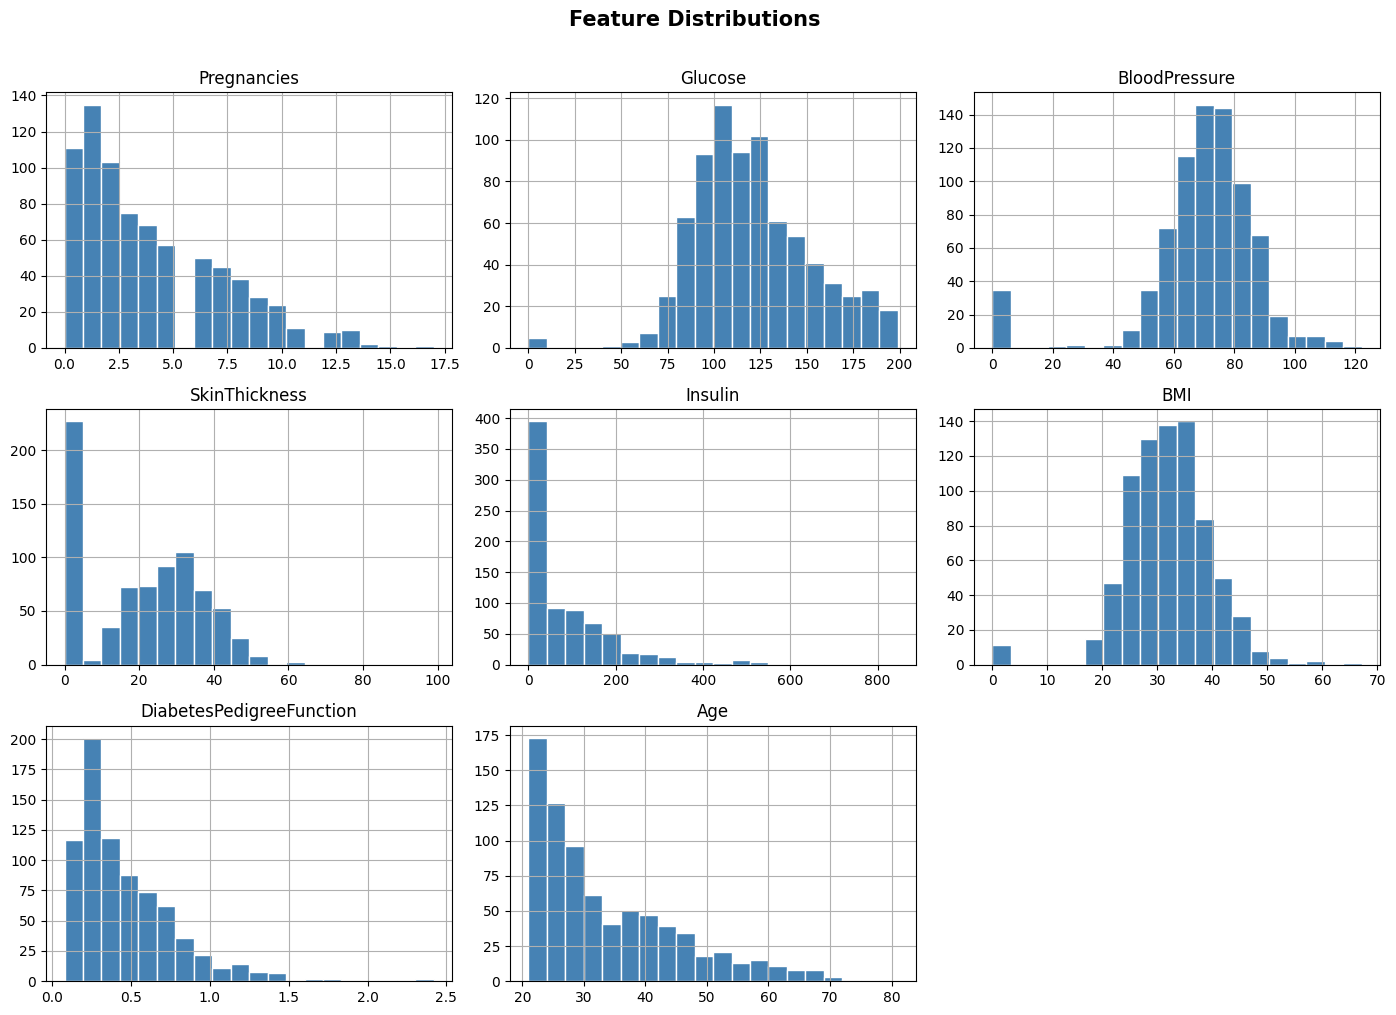

In [ ]:
df.drop('Outcome', axis=1).hist(
    figsize=(14, 10), bins=20,
    color='steelblue', edgecolor='white'
)
plt.suptitle('Feature Distributions', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

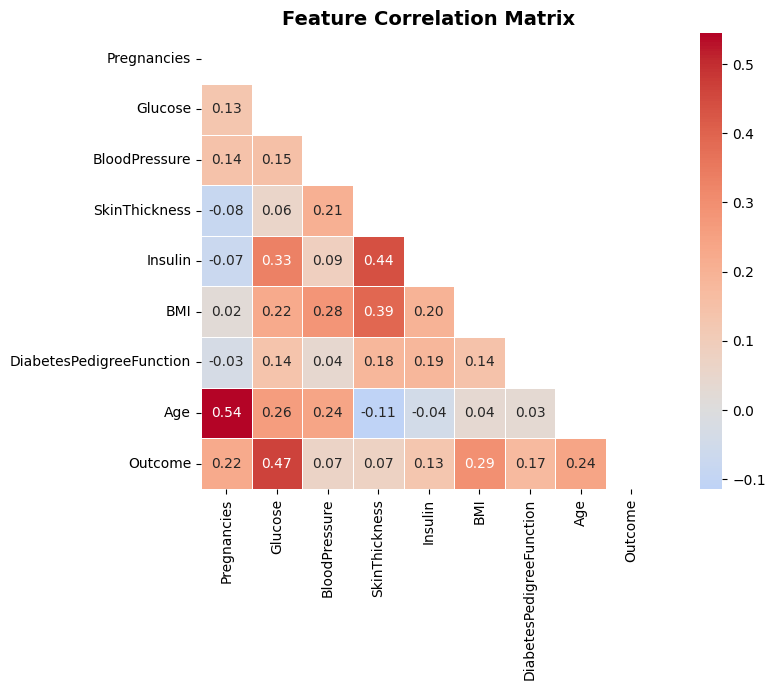

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.5, square=True
)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 2️⃣ Data Preprocessing

Replace biological zeros with column median

In [ ]:
replace_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']   # Pregnancies can be zero

for column in replace_zeros:
    median_val = df[column].replace(0, np.nan).median()
    df[column] = df[column].replace(0, median_val)

print("Zero values replaced with median in specified columns.")
print("\nNumber of zero values in each column after replacement:")
print(df.isin([0]).sum())

Zero values replaced with median in specified columns.

Number of zero values in each column after replacement:
Pregnancies                 111
Glucose                       0
BloodPressure                 0
SkinThickness                 0
Insulin                       0
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64


In [ ]:
df[replace_zeros].describe().T[['min', 'mean', 'max']]

,min,mean,max
Glucose,44.0,121.656250,199.0
BloodPressure,24.0,72.386719,122.0
SkinThickness,7.0,29.108073,99.0
Insulin,14.0,140.671875,846.0
BMI,18.2,32.455208,67.1


Separate features (X) and target (y)

In [ ]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

Features (X) shape: (768, 8)
Target (y) shape: (768,)


In [ ]:
X.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='object')

Perform Train/Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape:', y_test.shape)

X_train shape: (614, 8)
X_test shape: (154, 8)
y_train shape: (614,)
y_test shape: (154,)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (614, 8)
X_test_scaled shape: (154, 8)


## 3️⃣ Model Training

Models from sklearn

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
results = {}

LogisticRegresion

In [ ]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)

print("Accuracy:", acc)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7077922077922078

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



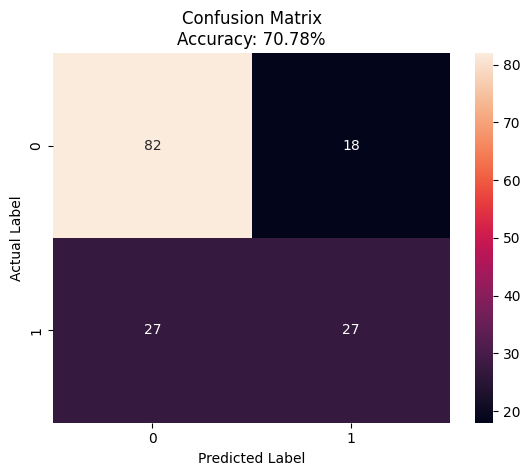

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True)
plt.title(f'Confusion Matrix\nAccuracy: {acc:.2%}')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

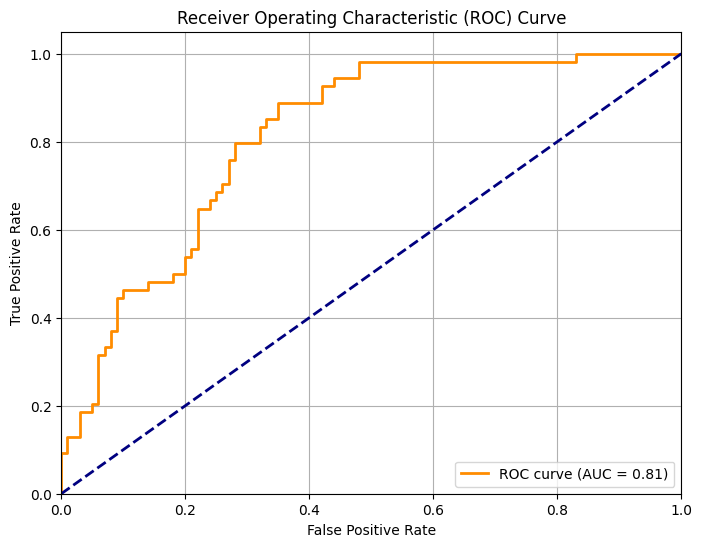

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob = model.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [ ]:
print(f"ROC-AUC Score: {(roc_auc*100):.2f}%")

ROC-AUC Score: 81.30%


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np

results['Logistic Regression'] = {
    'ROC_AUC': roc_auc,
    'Accuracy' : accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall'   : recall_score(y_test, y_pred),
    'F1 Score' : f1_score(y_test, y_pred),
    'y_pred': y_pred,
    'y_prob': y_prob,
    'model': model
}

print("Logistic Regression results stored in 'results' dictionary.")

Logistic Regression results stored in 'results' dictionary.


Random Forest (No Need Scaled Value)

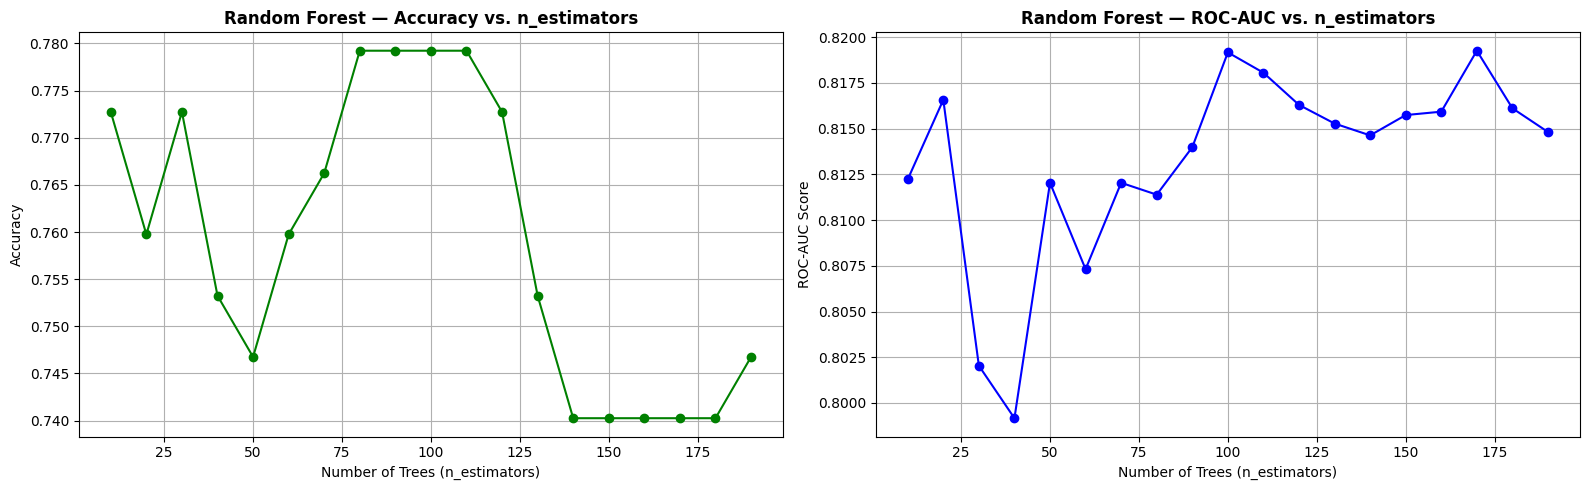

✅ Best n_estimators (by Accuracy): 80
   Accuracy: 0.7792
   ROC-AUC at best n_estimators (by Accuracy): 0.8114

⭐ Best n_estimators (by ROC-AUC): 170
   ROC-AUC: 0.8193
   Accuracy at best n_estimators (by ROC-AUC): 0.7403


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
import matplotlib.pyplot as plt

estimators = range(10, 200, 10)
acc_scores = []
roc_auc_scores = []

for n in estimators:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    y_prob = rf.predict_proba(X_test)[:, 1]

    acc_scores.append(accuracy_score(y_test, y_pred))
    roc_auc_scores.append(roc_auc_score(y_test, y_prob))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot for Accuracy
axes[0].plot(estimators, acc_scores, marker='o', color='green')
axes[0].set_title('Random Forest — Accuracy vs. n_estimators', fontweight='bold')
axes[0].set_xlabel('Number of Trees (n_estimators)')
axes[0].set_ylabel('Accuracy')
axes[0].grid(True)

# Plot for ROC-AUC
axes[1].plot(estimators, roc_auc_scores, marker='o', color='blue')
axes[1].set_title('Random Forest — ROC-AUC vs. n_estimators', fontweight='bold')
axes[1].set_xlabel('Number of Trees (n_estimators)')
axes[1].set_ylabel('ROC-AUC Score')
axes[1].grid(True)

plt.tight_layout()
plt.show()

best_n_by_accuracy_idx = acc_scores.index(max(acc_scores))
best_n_by_accuracy = list(estimators)[best_n_by_accuracy_idx]
best_accuracy = acc_scores[best_n_by_accuracy_idx]
roc_auc_at_best_accuracy = roc_auc_scores[best_n_by_accuracy_idx]

print(f'✅ Best n_estimators (by Accuracy): {best_n_by_accuracy}')
print(f'   Accuracy: {best_accuracy:.4f}')
print(f'   ROC-AUC at best n_estimators (by Accuracy): {roc_auc_at_best_accuracy:.4f}')

best_n_by_roc_auc_idx = roc_auc_scores.index(max(roc_auc_scores))
best_n_by_roc_auc = list(estimators)[best_n_by_roc_auc_idx]
best_roc_auc = roc_auc_scores[best_n_by_roc_auc_idx]
accuracy_at_best_roc_auc = acc_scores[best_n_by_roc_auc_idx]

print(f'\n⭐ Best n_estimators (by ROC-AUC): {best_n_by_roc_auc}')
print(f'   ROC-AUC: {best_roc_auc:.4f}')
print(f'   Accuracy at best n_estimators (by ROC-AUC): {accuracy_at_best_roc_auc:.4f}')

In [ ]:
model = RandomForestClassifier(n_estimators=best_n_by_roc_auc, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=170, random_state=42)

In [ ]:
y_pred = model.predict(X_test)

# Calculate accuracy
acc = accuracy_score(y_test, y_pred)

print("Accuracy:", acc)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7402597402597403

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.84      0.81       100
           1       0.65      0.56      0.60        54

    accuracy                           0.74       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.74      0.73       154



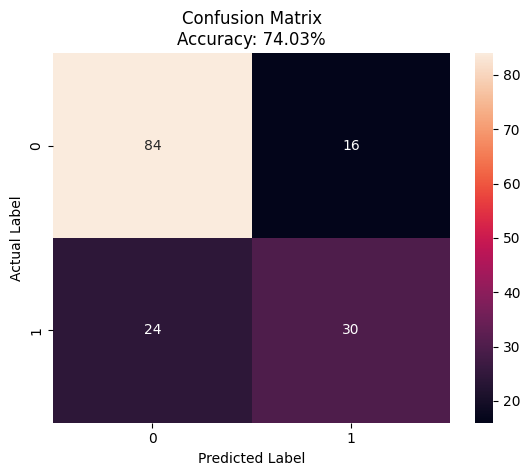

In [ ]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True)
plt.title(f'Confusion Matrix\nAccuracy: {acc:.2%}')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

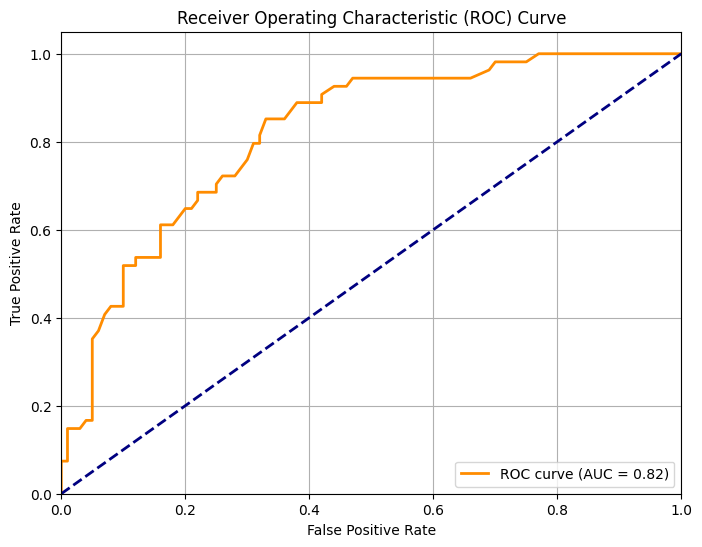

In [ ]:
y_prob = model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [ ]:
print(f"ROC-AUC Score: {(roc_auc*100):.2f}%")

ROC-AUC Score: 81.93%


In [ ]:
results['Random Forest'] = {
    'ROC_AUC': roc_auc,
    'Accuracy' : accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall'   : recall_score(y_test, y_pred),
    'F1 Score' : f1_score(y_test, y_pred),
    'y_pred': y_pred,
    'y_prob': y_prob,
    'model': model
}

print("Random Forest results stored in 'results' dictionary.")

Random Forest results stored in 'results' dictionary.


SVM

In [ ]:
model = SVC(probability=True, kernel='rbf', random_state=42)
model.fit(X_train_scaled, y_train)

SVC(probability=True, random_state=42)

In [ ]:
y_pred = model.predict(X_test_scaled)

# Calculate accuracy
acc = accuracy_score(y_test, y_pred)

print("Accuracy:", acc)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7402597402597403

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.84      0.81       100
           1       0.65      0.56      0.60        54

    accuracy                           0.74       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.74      0.73       154



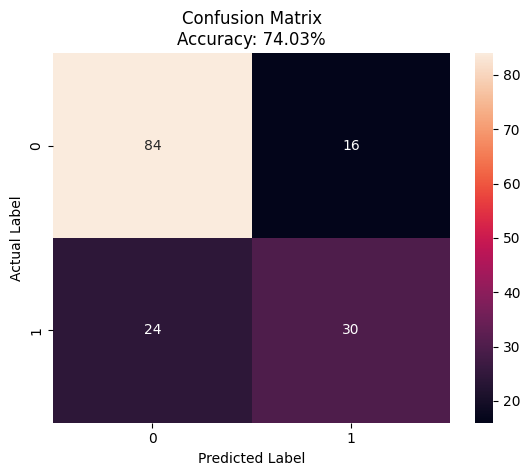

In [ ]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True)
plt.title(f'Confusion Matrix\nAccuracy: {acc:.2%}')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

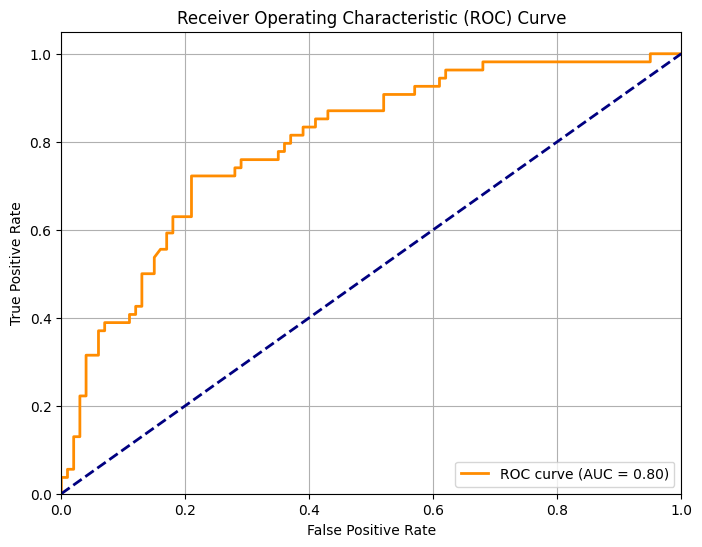

In [ ]:
y_prob = model.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [ ]:
print(f"ROC-AUC Score: {(roc_auc*100):.2f}%")

ROC-AUC Score: 79.64%


In [ ]:
results['SVM'] = {
    'ROC_AUC': roc_auc,
    'Accuracy' : accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall'   : recall_score(y_test, y_pred),
    'F1 Score' : f1_score(y_test, y_pred),
    'y_pred': y_pred,
    'y_prob': y_prob,
    'model': model
}

print("SVM results stored in 'results' dictionary.")

SVM results stored in 'results' dictionary.


Decision Tree  (No need Scaled Value)

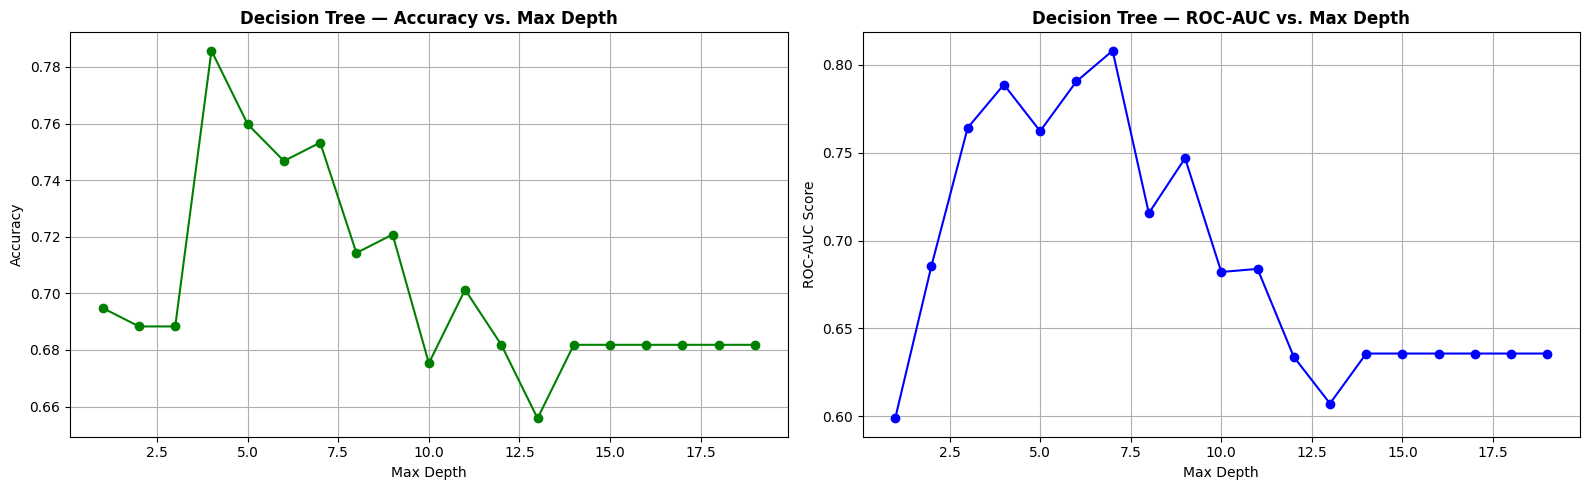

✅ Best max_depth (by Accuracy): 4
   Accuracy: 0.7857
   ROC-AUC at best max_depth (by Accuracy): 0.7887

⭐ Best max_depth (by ROC-AUC): 7
   ROC-AUC: 0.8080
   Accuracy at best max_depth (by ROC-AUC): 0.7532


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
import matplotlib.pyplot as plt

depths = range(1, 20)
roc_scores = []
accuracy_scores = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train, y_train)
    y_pred = dt.predict(X_test) # for accuracy
    y_prob = dt.predict_proba(X_test)[:, 1]  # for roc_auc

    accuracy_scores.append(accuracy_score(y_test, y_pred))
    roc_scores.append(roc_auc_score(y_test, y_prob))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot for Accuracy
axes[0].plot(depths, accuracy_scores, marker='o', color='green')
axes[0].set_title('Decision Tree — Accuracy vs. Max Depth', fontweight='bold')
axes[0].set_xlabel('Max Depth')
axes[0].set_ylabel('Accuracy')
axes[0].grid(True)

# Plot for ROC-AUC
axes[1].plot(depths, roc_scores, marker='o', color='blue')
axes[1].set_title('Decision Tree — ROC-AUC vs. Max Depth', fontweight='bold')
axes[1].set_xlabel('Max Depth')
axes[1].set_ylabel('ROC-AUC Score')
axes[1].grid(True)

plt.tight_layout()
plt.show()

best_d_by_accuracy_idx = accuracy_scores.index(max(accuracy_scores))
best_d_by_accuracy = depths[best_d_by_accuracy_idx]
best_accuracy = accuracy_scores[best_d_by_accuracy_idx]
roc_auc_at_best_accuracy = roc_scores[best_d_by_accuracy_idx]

print(f'✅ Best max_depth (by Accuracy): {best_d_by_accuracy}')
print(f'   Accuracy: {best_accuracy:.4f}')
print(f'   ROC-AUC at best max_depth (by Accuracy): {roc_auc_at_best_accuracy:.4f}')

best_d_by_roc_auc_idx = roc_scores.index(max(roc_scores))
best_d_by_roc_auc = depths[best_d_by_roc_auc_idx]
best_roc_auc = roc_scores[best_d_by_roc_auc_idx]
accuracy_at_best_roc_auc = accuracy_scores[best_d_by_roc_auc_idx]

print(f'\n⭐ Best max_depth (by ROC-AUC): {best_d_by_roc_auc}')
print(f'   ROC-AUC: {best_roc_auc:.4f}')
print(f'   Accuracy at best max_depth (by ROC-AUC): {accuracy_at_best_roc_auc:.4f}')

In [ ]:
model = DecisionTreeClassifier(max_depth=best_d_by_roc_auc, random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=7, random_state=42)

In [ ]:
y_pred = model.predict(X_test)

# Calculate accuracy
acc = accuracy_score(y_test, y_pred)

print("Accuracy:", acc)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7532467532467533

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.87      0.82       100
           1       0.69      0.54      0.60        54

    accuracy                           0.75       154
   macro avg       0.73      0.70      0.71       154
weighted avg       0.75      0.75      0.74       154



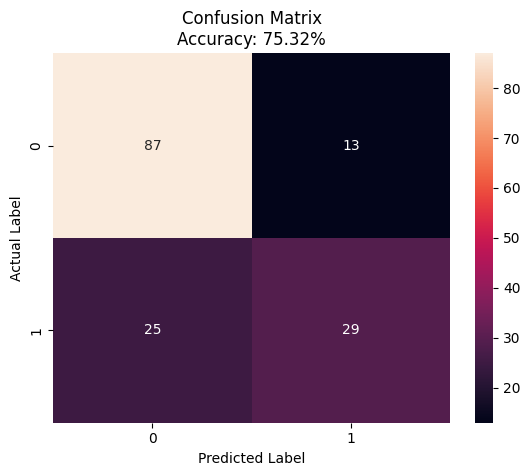

In [ ]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True)
plt.title(f'Confusion Matrix\nAccuracy: {acc:.2%}')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

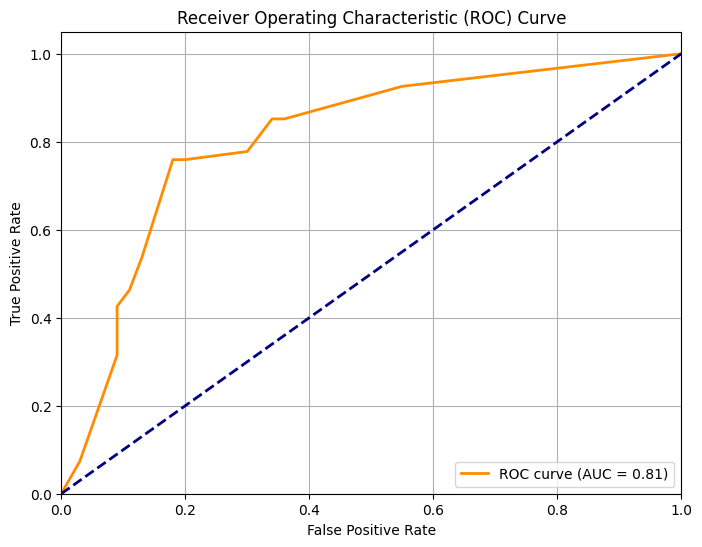

In [ ]:
y_prob = model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [ ]:
print(f"ROC-AUC Score: {(roc_auc*100):.2f}%")

ROC-AUC Score: 80.80%


In [ ]:
results['Decision Tree'] = {
    'ROC_AUC': roc_auc,
    'Accuracy' : accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall'   : recall_score(y_test, y_pred),
    'F1 Score' : f1_score(y_test, y_pred),
    'y_pred': y_pred,
    'y_prob': y_prob,
    'model': model
}

print("Decision Tree results stored in 'results' dictionary.")

Decision Tree results stored in 'results' dictionary.


KNN

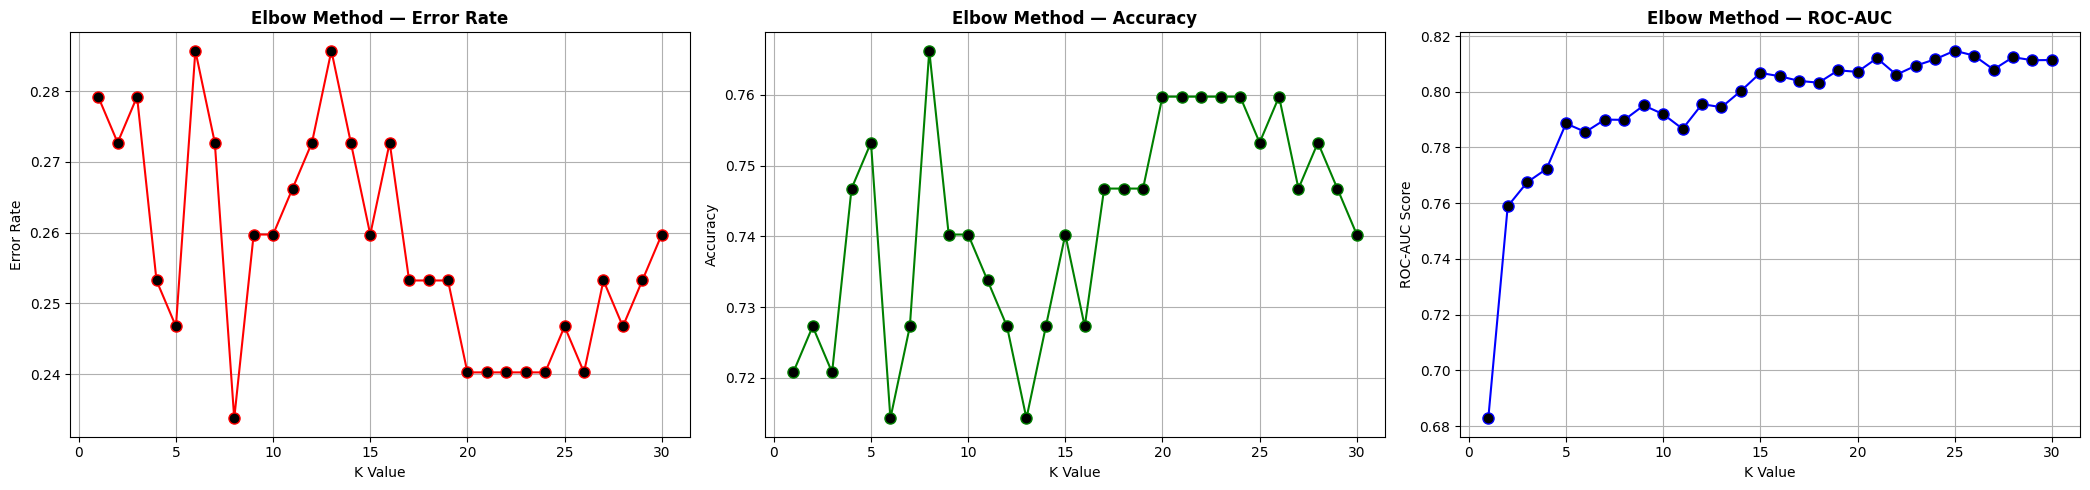

✅ Best K Value (by Accuracy): 8
   Accuracy: 0.7662
   ROC-AUC at best K (by Accuracy): 0.7899

⭐ Best K Value (by ROC-AUC): 25
   ROC-AUC: 0.8147
   Accuracy at best K (by ROC-AUC): 0.7532


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
import matplotlib.pyplot as plt

k_values = range(1, 31)
error_rates = []
accuracy_rates = []
roc_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    y_prob = knn.predict_proba(X_test_scaled)[:, 1]

    current_accuracy = accuracy_score(y_test, y_pred)
    accuracy_rates.append(current_accuracy)
    error_rates.append(1 - current_accuracy)
    roc_scores.append(roc_auc_score(y_test, y_prob))

fig, axes = plt.subplots(1, 3, figsize=(21, 5))


axes[0].plot(k_values, error_rates,
             color='red', marker='o',
             markerfacecolor='black', markersize=8)
axes[0].set_title('Elbow Method — Error Rate', fontweight='bold')
axes[0].set_xlabel('K Value')
axes[0].set_ylabel('Error Rate')
axes[0].grid(True)

axes[1].plot(k_values, accuracy_rates,
             color='green', marker='o',
             markerfacecolor='black', markersize=8)
axes[1].set_title('Elbow Method — Accuracy', fontweight='bold')
axes[1].set_xlabel('K Value')
axes[1].set_ylabel('Accuracy')
axes[1].grid(True)

# Plot for ROC-AUC
axes[2].plot(k_values, roc_scores,
             color='blue', marker='o',
             markerfacecolor='black', markersize=8)
axes[2].set_title('Elbow Method — ROC-AUC', fontweight='bold')
axes[2].set_xlabel('K Value')
axes[2].set_ylabel('ROC-AUC Score')
axes[2].grid(True)

plt.tight_layout()
plt.show()

best_k_by_accuracy_idx = accuracy_rates.index(max(accuracy_rates))
best_k_by_accuracy = k_values[best_k_by_accuracy_idx]
best_accuracy = accuracy_rates[best_k_by_accuracy_idx]
best_roc_auc_at_best_accuracy = roc_scores[best_k_by_accuracy_idx]

print(f'✅ Best K Value (by Accuracy): {best_k_by_accuracy}')
print(f'   Accuracy: {best_accuracy:.4f}')
print(f'   ROC-AUC at best K (by Accuracy): {best_roc_auc_at_best_accuracy:.4f}')

best_k_by_roc_auc_idx = roc_scores.index(max(roc_scores))
best_k_by_roc_auc = k_values[best_k_by_roc_auc_idx]
best_roc_auc = roc_scores[best_k_by_roc_auc_idx]
accuracy_at_best_roc_auc = accuracy_rates[best_k_by_roc_auc_idx]

print(f'\n⭐ Best K Value (by ROC-AUC): {best_k_by_roc_auc}')
print(f'   ROC-AUC: {best_roc_auc:.4f}')
print(f'   Accuracy at best K (by ROC-AUC): {accuracy_at_best_roc_auc:.4f}')

In [ ]:
model = KNeighborsClassifier(n_neighbors=best_k_by_roc_auc)
model.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=25)

In [ ]:
y_pred = model.predict(X_test_scaled)

# Calculate accuracy
acc = accuracy_score(y_test, y_pred)

print("Accuracy:", acc)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7532467532467533

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.86      0.82       100
           1       0.68      0.56      0.61        54

    accuracy                           0.75       154
   macro avg       0.73      0.71      0.72       154
weighted avg       0.75      0.75      0.75       154



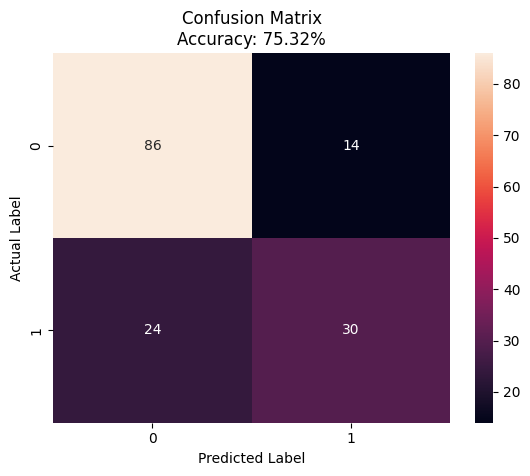

In [ ]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True)
plt.title(f'Confusion Matrix\nAccuracy: {acc:.2%}')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

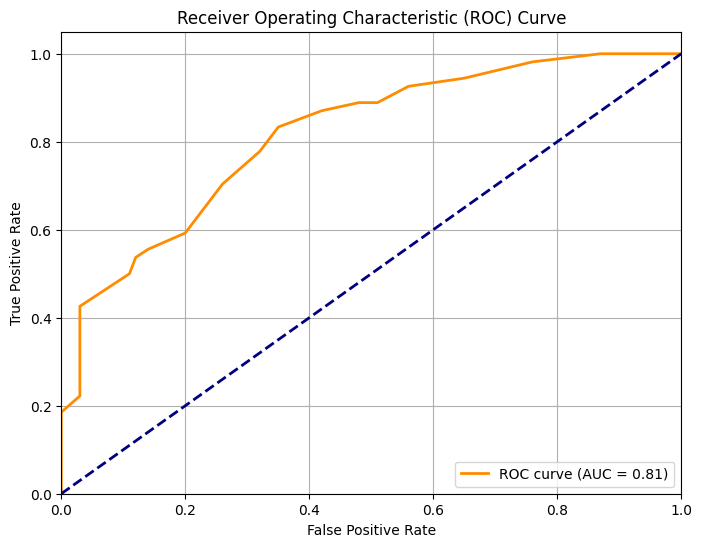

In [ ]:
y_prob = model.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [ ]:
print(f"ROC-AUC Score: {(roc_auc*100):.2f}%")

ROC-AUC Score: 81.47%


In [ ]:
results['KNN'] = {
    'ROC_AUC': roc_auc,
    'Accuracy' : accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall'   : recall_score(y_test, y_pred),
    'F1 Score' : f1_score(y_test, y_pred),
    'y_pred': y_pred,
    'y_prob': y_prob,
    'model': model
}

print("KNN results stored in 'results' dictionary.")

KNN results stored in 'results' dictionary.


## Compare models visually

In [ ]:
import pandas as pd

summary_data = []
for model_name, metrics in results.items():
    summary_data.append({
        'Model': model_name,
        'ROC-AUC': metrics['ROC_AUC'],
        'Accuracy': metrics['Accuracy'],
        'Precision': metrics['Precision'],
        'Recall': metrics['Recall'],
        'F1 Score': metrics['F1 Score']
    })

results_df = pd.DataFrame(summary_data)

results_df = results_df.sort_values(by='ROC-AUC', ascending=False).reset_index(drop=True)

def highlight_max(s):
    is_max = s == s.max()
    return ['background-color: green' if v else '' for v in is_max]


print("\n--- Model Performance Summary ---\n")

styled_df = results_df.style.apply(highlight_max, subset=['ROC-AUC', 'Accuracy', 'Precision', 'Recall', 'F1 Score'])


from IPython.display import display
display(styled_df)


--- Model Performance Summary ---



,Model,ROC-AUC,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.819259,0.740260,0.652174,0.555556,0.600000
1,KNN,0.814722,0.753247,0.681818,0.555556,0.612245
2,Logistic Regression,0.812963,0.707792,0.600000,0.500000,0.545455
3,Decision Tree,0.807963,0.753247,0.690476,0.537037,0.604167
4,SVM,0.796389,0.740260,0.652174,0.555556,0.600000


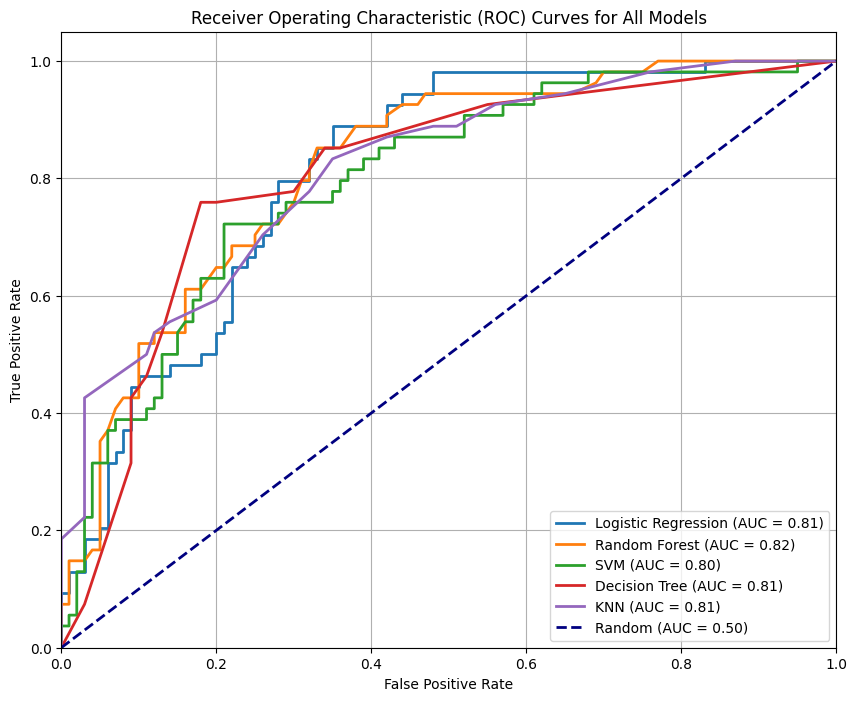

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 8))

for model_name, metrics in results.items():
    y_test = y_test # Assuming y_test is the same for all models
    y_prob = metrics['y_prob']

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, lw=2, label=f'{model_name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curves for All Models')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

## Best Model Selection

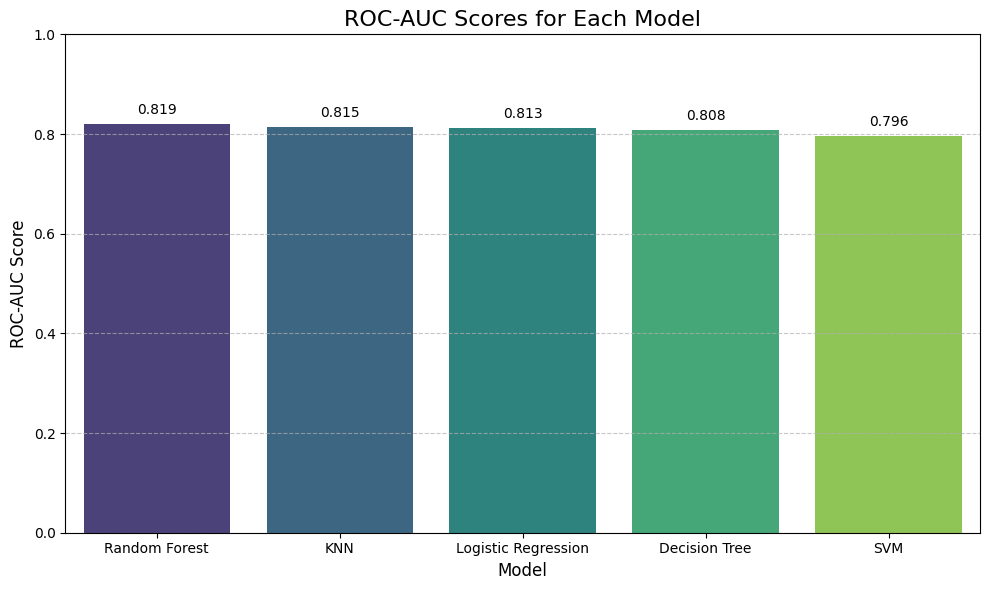

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='ROC-AUC', data=results_df, palette='viridis', hue='Model', legend=False)
plt.title('ROC-AUC Scores for Each Model', fontsize=16)
plt.xlabel('Model', fontsize=12)
plt.ylabel('ROC-AUC Score', fontsize=12)
plt.ylim(0.0, 1.0)

for index, row in results_df.iterrows():
    plt.text(index, row['ROC-AUC'] + 0.02, round(row['ROC-AUC'], 3), color='black', ha="center")

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# --- Identify best model (highest ROC-AUC) ---
print('=== Performance Summary ===')
print(results_df.to_string())

best_name = results_df.loc[results_df['ROC-AUC'].idxmax(), 'Model']
best_auc  = results_df.loc[results_df['ROC-AUC'].idxmax(), 'ROC-AUC']
best_acc  = results_df.loc[results_df['ROC-AUC'].idxmax(), 'Accuracy']

print(f'\n🏆 Best Model   : {best_name}')
print(f'   ROC-AUC     : {best_auc:.4f}')
print(f'   Accuracy    : {best_acc:.4f}')

=== Performance Summary ===
                 Model   ROC-AUC  Accuracy  Precision    Recall  F1 Score
0        Random Forest  0.819259  0.740260   0.652174  0.555556  0.600000
1                  KNN  0.814722  0.753247   0.681818  0.555556  0.612245
2  Logistic Regression  0.812963  0.707792   0.600000  0.500000  0.545455
3        Decision Tree  0.807963  0.753247   0.690476  0.537037  0.604167
4                  SVM  0.796389  0.740260   0.652174  0.555556  0.600000

🏆 Best Model   : Random Forest
   ROC-AUC     : 0.8193
   Accuracy    : 0.7403


## Best Model Save

In [ ]:
import joblib

best_model = results[best_name]['model']

joblib.dump(best_model, 'diabetes_model.pkl')
print(f'✅ Best model ({best_name}) saved as "diabetes_model.pkl"')

✅ Best model (Random Forest) saved as "diabetes_model.pkl"


## Load The Best Model

In [ ]:
import joblib

loaded_model = joblib.load('diabetes_model.pkl')

print('✅ Best model loaded successfully!')

✅ Best model loaded successfully!


In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score

y_pred_loaded = loaded_model.predict(X_test)
y_prob_loaded = loaded_model.predict_proba(X_test)[:, 1]

accuracy_loaded = accuracy_score(y_test, y_pred_loaded)

# Calculate ROC-AUC
roc_auc_loaded = roc_auc_score(y_test, y_prob_loaded)

print(f"Accuracy of the loaded model: {accuracy_loaded:.4f}")
print(f"ROC-AUC of the loaded model: {roc_auc_loaded:.4f}")

Accuracy of the loaded model: 0.7403
ROC-AUC of the loaded model: 0.8193
